# Data Wrangling and Feature Engineering on Developer Survey Data

## Objective:
* Clean the dataset and remove inconsistencies
* Handle missing values properly
* Convert categorical data into usable form
* Scale numerical features
* Classify records by experience level
* Standardize values across the dataset
* Create useful features for analysis
* Prepare the data for meaningful insights

In [1]:
# Install Pandas for Data Handling
!pip install pandas

# Install Matplotlib (for visualization basic charts)
!pip install matplotlib

# Install Seaborn (for beautiful, ready-made charts)
!pip install seaborn

# Install Scikit-Learn for Encoding Data
!pip install scikit-learn


In [2]:
# Import the necessary module
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np # mathematical operats
import seaborn as sns

# Task 1:  Load the Dataset

In [3]:

# Step 1: Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)

#  Step 2: Display the first few rows
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### Key Insights:
* The dataset loaded successfully and shows the first five survey responses.
* Each row represents one respondent (ResponseId).
* Columns include age, employment, remote work, coding activities, education, and compensation.
* Some values are missing (NaN) in certain columns.
* The dataset is large, with 114 columns.

# Task 2: Explore the Dataset

In [4]:
# Step 1: Summarize Dataset (Data Types, Counts, Missing Values)

# 1.1: # Show column data types and non-null counts
print(" Show column data types and non-null counts:")
df.info()



 Show column data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


### Key Insights:
* The dataset has 65,437 rows and 114 columns.
* It contains:
  * 100 text (object) columns
  * 13 numeric float columns
  * 1 numeric integer column
* The dataset size is about 56.9 MB.


In [5]:
# 1.2: Missing Values Per Column
df.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

### Key Insights:
* This table shows how many values are missing in each column.
* Some columns have no missing values (like ResponseId, MainBranch, Age, Employment).
* Columns like RemoteWork, CodingActivities, and EdLevel have some missing values.
* The ConvertedCompYearly (salary) column has a large number of missing values.
* This helps identify which columns need cleaning or imputation.

In [6]:
# 1.3: Dataset Summary — Data Types, Non-Null Counts, and Missing Values(cleaner output table)
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.count(),
    "Missing Values": df.isnull().sum()
})

summary


,Data Type,Non-Null Count,Missing Values
ResponseId,int64,65437,0
MainBranch,object,65437,0
Age,object,65437,0
Employment,object,65437,0
RemoteWork,object,54806,10631
...,...,...,...
JobSatPoints_11,float64,29445,35992
SurveyLength,object,56182,9255
SurveyEase,object,56238,9199
ConvertedCompYearly,float64,23435,42002


In [7]:
# 1.3: Generate Basic Statistics for Numerical Columns
df.describe()


,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


* This table shows summary statistics for numeric columns.
* count = number of non-missing values.
* mean = average value.
* min and max = smallest and largest values.


# Task 3: Identifying and Removing Inconsistencies

In [8]:
# Step 1 — View unique country values
df["Country"].unique()

array(['United States of America',
       'United Kingdom of Great Britain and Northern Ireland', 'Canada',
       'Norway', 'Uzbekistan', 'Serbia', 'Poland', 'Philippines',
       'Bulgaria', 'Switzerland', 'India', 'Germany', 'Ireland', 'Italy',
       'Ukraine', 'Australia', 'Brazil', 'Japan', 'Austria',
       'Iran, Islamic Republic of...', 'France', 'Saudi Arabia',
       'Romania', 'Turkey', 'Nepal', 'Algeria', 'Sweden', 'Netherlands',
       'Croatia', 'Pakistan', 'Czech Republic',
       'Republic of North Macedonia', 'Finland', 'Slovakia',
       'Russian Federation', 'Greece', 'Israel', 'Belgium', 'Mexico',
       'United Republic of Tanzania', 'Hungary', 'Argentina', 'Portugal',
       'Sri Lanka', 'Latvia', 'China', 'Singapore', 'Lebanon', 'Spain',
       'South Africa', 'Lithuania', 'Viet Nam', 'Dominican Republic',
       'Indonesia', 'Kosovo', 'Morocco', 'Taiwan', 'Georgia',
       'San Marino', 'Tunisia', 'Bangladesh', 'Nigeria', 'Liechtenstein',
       'Denmark', 'Ecu

### Key Insights:
* The Country column contains survey responses from people across many different countries.
* A few country names appear in long or extended formats (e.g., “United Kingdom of Great Britain and Northern Ireland”).


In [9]:
#  Step 2 — Find the most common values
df["Country"].value_counts()


Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
                                                        ...  
Micronesia, Federated States of...                          1
Nauru                                                       1
Chad                                                        1
Djibouti                                                    1
Solomon Islands                                             1
Name: count, Length: 185, dtype: int64

### Key Insights:
* This result shows how many respondents are from each country.
* The United States has the highest number of responses, followed by Germany, India, and the UK.
* Some countries have only one respondent.
* There are 185 countries in total in the dataset.

In [10]:
# Step 3:  Detect inconsistent formatting
df["Country"] = df["Country"].str.strip().str.title()

df["Country"].head(3)


0                             United States Of America
1    United Kingdom Of Great Britain And Northern I...
2    United Kingdom Of Great Britain And Northern I...
Name: Country, dtype: object

### Key Insights:
* Cleaned (no extra spaces)
* Converted to Title Case
* Consistent in formatting

In [11]:
# Step 4: # Verify
invalid_values = df[df["Country"] != df["Country"].str.title()]
invalid_values["Country"].unique()


array([nan], dtype=object)

### Key Insights:
* There are no incorrectly formatted country names
* The only entries detected are NaN (missing values)
* All valid country values are already in Title Case and clean

In [12]:
# Step 5: Define the invalid values in lowercase

invalid_countries = [
    "unknown", "n/a", "none", "not disclosed",
    "prefer not to say", "-", "", "other"
]

# Step 6: Identify invalid entries
df_inconsistent =df[df["Country"].isin(invalid_countries)]
df_inconsistent


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat


### Key Insights:
There are no invalid country entries based on your defined list

# Standardizing Country Names Using Mapping and Validation

In [13]:
# Step 1: Create a mapping dictionary
country_map = {
    "united states of america": "united states",
    "united states": "united states",

    "united kingdom of great britain and northern ireland": "united kingdom",
    "united kingdom": "united kingdom",
    "england": "united kingdom",
    "scotland": "united kingdom",

    "russian federation": "russia",
    "republic of korea": "south korea"
}
print("Map created successfully")

Map created successfully


In [14]:
# Step 2: Apply mapping to the Country column

df["Country"] = df["Country"].str.lower().str.strip()
df["Country"] = df["Country"].replace(country_map)


In [15]:
# Step 3: check updated results
df["Country"].value_counts().head(10)


Country
united states     11095
germany            4947
india              4231
united kingdom     3224
ukraine            2672
france             2110
canada             2104
poland             1534
netherlands        1449
brazil             1375
Name: count, dtype: int64

### Key Insights:
* The mapping and standardization were applied successfully.
* Long or inconsistent country names have now been merged into clean, consistent values (for example: “United States of America” is now “united states”).
* The dataset now shows top 10 most frequent countries clearly.
*The values are easier to read and analyze because duplicates and variations were removed.

# Task 4:  Encoding Categorical Variables
### (converting text categories into numerical values.)
## Label Encoding

In [16]:
# Step 1: Label Encoding (assign numbers to categories)

# Imports the LabelEncoder class from scikit-learn( This tool converts text categories into numeric values.)
from sklearn.preprocessing import LabelEncoder

# Create LebelEncoder object.
le = LabelEncoder() 

# Apply Label Encoding to the Employment Column
df["Employment_Encoded"] = le.fit_transform(df["Employment"]) 

# Step 1.1: View the encoded values
df[["Employment", "Employment_Encoded"]].head(10)




,Employment,Employment_Encoded
0,"Employed, full-time",0
1,"Employed, full-time",0
2,"Employed, full-time",0
3,"Student, full-time",80
4,"Student, full-time",80
5,"Student, full-time",80
6,"Employed, full-time",0
7,"Student, full-time;Not employed, but looking f...",91
8,"Employed, full-time",0
9,"Independent contractor, freelancer, or self-em...",44


### Important insight
* The numbers do not represent rank or meaning.
* They are just labels for different categories.
* So 0 is not better or higher than 80 — they just identify different groups.

In [17]:
# Step 1.2: verify how many categories exist
len(le.classes_)


110

### Important insight
* The Employment column has 110 unique categories
* Categories are numbered from 0 to 109
* Each number represents a different category
* The number depends on the category’s alphabetical position, not quantity or importance


## One-Hot Encoding 
### For column Employment

In [18]:
# Step 1: View only top 20 categories (easier to read)
df["Employment"].value_counts().head(20)


Employment
Employed, full-time                                                                        39041
Independent contractor, freelancer, or self-employed                                        4846
Student, full-time                                                                          4709
Employed, full-time;Independent contractor, freelancer, or self-employed                    3557
Not employed, but looking for work                                                          2341
Employed, part-time                                                                         1266
Student, full-time;Employed, part-time                                                      1115
Employed, full-time;Student, full-time                                                       897
Employed, full-time;Student, part-time                                                       839
Student, full-time;Not employed, but looking for work                                        686
Not employed, and n

### Important insight
* The most common employment type is Employed, full-time.
* Other common groups include freelancers/self-employed and full-time students.
* Some entries contain more than one employment type in the same row (example: Employed, full-time; Student, part-time).
* The column also includes unemployed, part-time, retired, and prefer-not-to-say categories.
* Because entries are mixed and multi-value, this column may require cleaning or converting into multiple encoded columns.

#### Step 2: Define meaningful employment groups
 We will group detailed responses into broader categories:
* Full-time Employed
* Part-time Employed
* Self-employed / Freelancer
* Student
* Unemployed
* Retired
* Prefer not to say
* Other / Mixed

In [19]:
# Step 2: Create a mapping function for groing employment values

def group_employment(value):

    # Convert to lowercase and replace hyphens with spaces
    # This helps match variations like "full-time" and "full time"
    value = str(value).lower().replace("-", " ")

    if "full time" in value:
        return "Employed — Full Time"

    elif "part time" in value:
        return "Employed — Part Time"

    elif "independent contractor" in value or "self employed" in value or "freelancer" in value:
        return "Self-Employed / Freelancer"

    elif "student" in value:
        return "Student"

    elif "not employed, but looking" in value:
        return "Unemployed — Looking for Work"

    elif "not employed, and not looking" in value:
        return "Unemployed — Not Looking"

    elif "retired" in value:
        return "Retired"

    elif "prefer not to say" in value:
        return "Prefer Not To Say"

    else:
        return "Mixed / Other"


In [20]:
# Step 3: Apply it
df["Employment_Grouped"] = df["Employment"].apply(group_employment)


In [21]:
# Step 4: Check grouped results
df["Employment_Grouped"].value_counts()


Employment_Grouped
Employed — Full Time             52717
Self-Employed / Freelancer        5363
Employed — Part Time              3250
Unemployed — Looking for Work     2386
Unemployed — Not Looking           650
Prefer Not To Say                  546
Retired                            525
Name: count, dtype: int64

### Important insight
* Most respondents are Employed — Full Time (52,717).
* The next largest groups are Self-Employed/Freelancer (5,363) and Employed — Part Time (3,250).
* A smaller number are Unemployed — Looking for Work (2,386).
* Very few respondents are Unemployed — Not Looking, Retired, or Prefer Not To Say.
* Grouping made the Employment data clearer and easier to analyze.

In [22]:
# Step 5: Apply One-Hot Encoding to the grouped column
df_encoded = pd.get_dummies(df, columns=["Employment_Grouped"], prefix="Emp", drop_first=False)


In [23]:
# Step 6: Check the result
df_encoded.filter(like="Emp_").head()


,Emp_Employed — Full Time,Emp_Employed — Part Time,Emp_Prefer Not To Say,Emp_Retired,Emp_Self-Employed / Freelancer,Emp_Unemployed — Looking for Work,Emp_Unemployed — Not Looking
0,True,False,False,False,False,False,False
1,True,False,False,False,False,False,False
2,True,False,False,False,False,False,False
3,True,False,False,False,False,False,False
4,True,False,False,False,False,False,False


### Important insight
* Each column represents one employment group created by one-hot encoding.
* The values are True / False:
* True → the person belongs to that category
* False → the person does not belong to that category

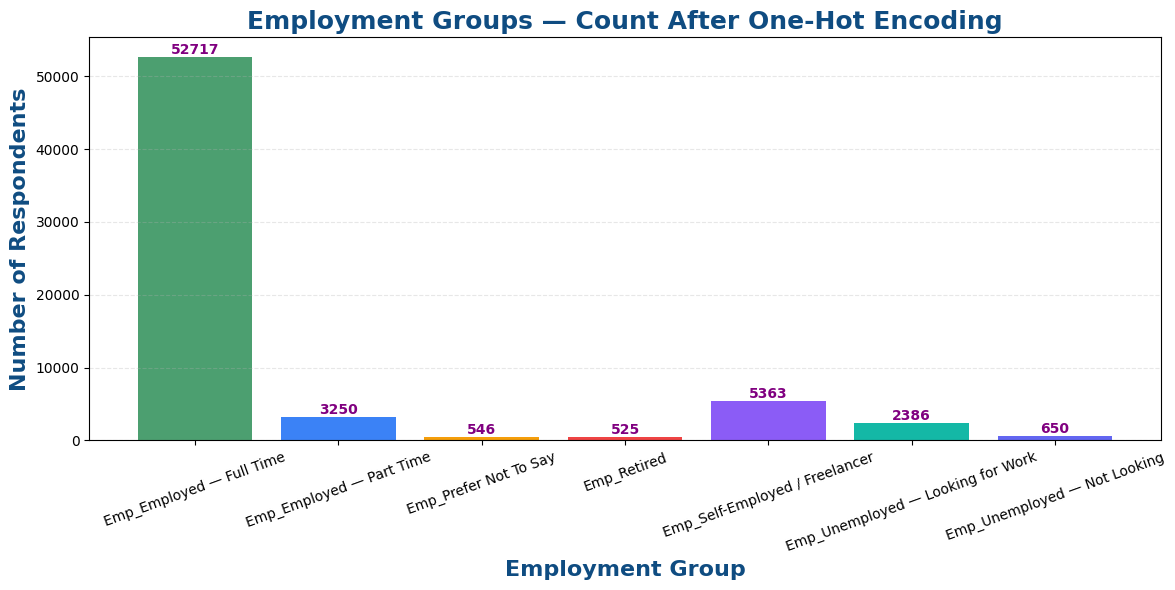

In [24]:
# Step 7: Employment Groups — Count After One-Hot Encoding
import matplotlib.pyplot as plt

emp_cols = [col for col in df_encoded.columns if col.startswith("Emp_")]
counts = df_encoded[emp_cols].sum()

plt.figure(figsize=(12,6))

bars = plt.bar(
    counts.index,
    counts.values,
    color=["#4C9F70", "#3B82F6", "#F59E0B", "#EF4444", "#8B5CF6", "#14B8A6", "#6366F1"]
)

# ----- Title & Axis Styling -----
plt.title(
    "Employment Groups — Count After One-Hot Encoding",
    fontsize=18,
    fontweight="bold",
    color="#0F4C81"
)

plt.xlabel("Employment Group", fontsize=16, color="#0F4C81", fontweight="bold")
plt.ylabel("Number of Respondents", fontsize=16, color="#0F4C81", fontweight="bold")

plt.xticks(rotation=20, fontsize=10, color="black")
plt.yticks(fontsize=10, color="black")

# ----- Light Grid for Readability -----
plt.grid(axis="y", linestyle="--", alpha=0.3)

# ----- Display values on bars -----
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        color="purple",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()



# Task 5: Handling Missing Values

In [25]:
# Step 1: Identify columns with the highest number of missing values
missing_cols = df.isnull().sum().sort_values(ascending=False)
missing_cols.head(10)


AINextMuch less integrated       64289
AINextLess integrated            63082
AINextNo change                  52939
AINextMuch more integrated       51999
EmbeddedAdmired                  48704
EmbeddedWantToWorkWith           47837
EmbeddedHaveWorkedWith           43223
ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
dtype: int64

### Important insight
* Many respondents did not answer these questions
* Especially AI and Embedded-Tech related questions
* Salary column also has large missing data

In [26]:
# Step 2: Impute missing values in numerical columns using Mean or Median
# Fill with median (Better for salary), Median is used because salary data often contains outliers (very high values)
mean_comp = df["ConvertedCompYearly"].mean()
df["ConvertedCompYearly"].fillna(mean_comp, inplace=True)

# Step 3: Check if any missing values remain
df["ConvertedCompYearly"].isnull().sum()



/tmp/ipykernel_4424/1120683904.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ConvertedCompYearly"].fillna(mean_comp, inplace=True)


np.int64(0)

### Important insight
* Missing values in the ConvertedCompYearly column were filled using the mean value.
* After imputation, the number of missing values in this column is 0.
* This confirms that the missing-value treatment was successfully applied.

In [27]:
# Step 4: Impute missing values in categorical columns using the Most Frequent Value (Mode)
most_frequent_remote = df["RemoteWork"].mode()[0]
df["RemoteWork"].fillna(most_frequent_remote, inplace=True)

# Step 5: Check if any missing values remain
df["RemoteWork"].isnull().sum()

/tmp/ipykernel_4424/3327815624.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["RemoteWork"].fillna(most_frequent_remote, inplace=True)


np.int64(0)

### Important insight
* Missing values in the RemoteWork column were filled using the Most Frequent Value.
* After imputation, the number of missing values in this column is 0.
* This confirms that the missing-value treatment was successfully applied.

# Task 6:  Feature Scaling and Transformation
### For column-  ConvertedCompYearly

In [28]:
# Step 1 — Min-Max Scaling (Normalize to 0–1 range)
# Min–Max Scaling
min_val = df["ConvertedCompYearly"].min()
max_val = df["ConvertedCompYearly"].max()

df["ConvertedCompYearly_MinMax"] = (
    (df["ConvertedCompYearly"] - min_val) / (max_val - min_val)
)


In [29]:
# Step 1.1: Confirm there are no values outside the range
(
    df["ConvertedCompYearly_MinMax"] < 0
).sum(), (
    df["ConvertedCompYearly_MinMax"] > 1
).sum()


(np.int64(0), np.int64(0))

### Important insight

* The first 0 → no values are below 0
* The second 0 → no values are above 1
* This confirms that all scaled values are correctly within the 0–1 range.


In [30]:
# Step 2 — Log Transform to Reduce Skewness

# Add 1 to avoid log(0) errors
df["ConvertedCompYearly_Log"] = np.log(df["ConvertedCompYearly"] + 1)

# 2.1 Compare original vs log-transformed values
df[["ConvertedCompYearly", "ConvertedCompYearly_Log"]].head()



,ConvertedCompYearly,ConvertedCompYearly_Log
0,86155.287263,11.363918
1,86155.287263,11.363918
2,86155.287263,11.363918
3,86155.287263,11.363918
4,86155.287263,11.363918


### Important insight
* The salary is a large number
* After log transform, it becomes a smaller, compressed value
* The transformation was applied correctly and consistently

In [31]:
# Step 3: Summary of Salary Before and After Min-Max Scaling and Log Transform
df[["ConvertedCompYearly", 
    "ConvertedCompYearly_MinMax", 
    "ConvertedCompYearly_Log"]].describe()


,ConvertedCompYearly,ConvertedCompYearly_MinMax,ConvertedCompYearly_Log
count,6.543700e+04,65437.000000,65437.000000
mean,8.615529e+04,0.005300,11.156906
std,1.117614e+05,0.006875,0.884085
min,1.000000e+00,0.000000,0.693147
25%,8.615529e+04,0.005300,11.363918
50%,8.615529e+04,0.005300,11.363918
75%,8.615529e+04,0.005300,11.363918
max,1.625660e+07,1.000000,16.604010


### Important insight
* Original salary values have a very large range and contain extreme outliers.
* Min–Max Scaling successfully transformed the salary values into the 0–1 range.
* Log Transform compressed large salary values and reduced the spread of the data.
* The transformed salary values are now more balanced and suitable for analysis

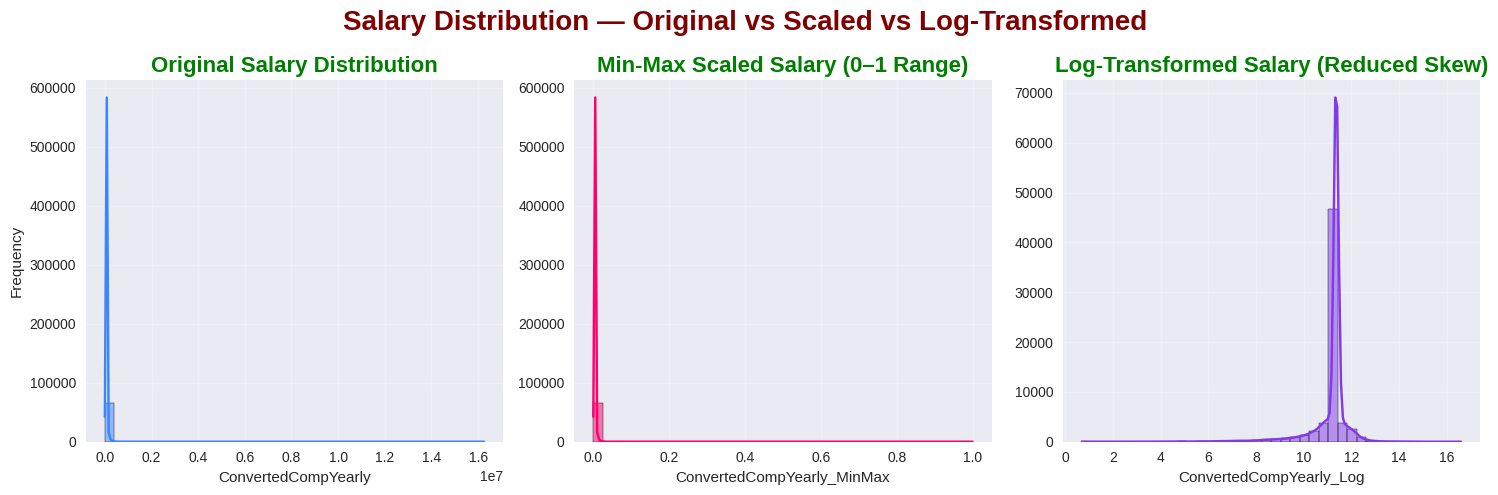

In [32]:
# Step 4: Histogram - Salary Distribution Comparison — Original vs Min-Max Scaled vs Log-Transformed

plt.style.use("seaborn-v0_8")

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Color theme 
colors = ["#3A86FF", "#FF006E", "#8338EC"]

# 1.  Original Salary 
sns.histplot(df["ConvertedCompYearly"], bins=40, kde=True,
             color=colors[0], ax=axes[0])
axes[0].set_title("Original Salary Distribution", fontsize=16, fontweight="bold", color="green")
axes[0].set_xlabel("ConvertedCompYearly")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.25)

# 2.  Min-Max Normalized 
sns.histplot(df["ConvertedCompYearly_MinMax"], bins=40, kde=True,
             color=colors[1], ax=axes[1])
axes[1].set_title("Min-Max Scaled Salary (0–1 Range)", fontsize=16, fontweight="bold",color="green" )
axes[1].set_xlabel("ConvertedCompYearly_MinMax")
axes[1].set_ylabel("")
axes[1].grid(alpha=0.25)

# 3.  Log-Transformed ---
sns.histplot(df["ConvertedCompYearly_Log"], bins=40, kde=True,
             color=colors[2], ax=axes[2])
axes[2].set_title("Log-Transformed Salary (Reduced Skew)", fontsize=16, fontweight="bold", color="green")
axes[2].set_xlabel("ConvertedCompYearly_Log")
axes[2].set_ylabel("")
axes[2].grid(alpha=0.25)

plt.suptitle("Salary Distribution — Original vs Scaled vs Log-Transformed",
             fontsize=20, fontweight="bold", color="maroon")

plt.tight_layout()
plt.show()


### Important insight
* The original salary data is highly skewed due to extreme high-value outliers.
* Min-Max scaling rescales the values to a 0–1 range but does not change the skewness.
* The Log Transform effectively compresses large values and produces a more balanced and less skewed distribution.

# Task 7: Feature Engineering
###  Create a new column `ExperienceLevel` based on the `YearsCodePro` column:

In [33]:
# Step 1 — Check basic details of the column
df["YearsCodePro"].head()



0    NaN
1     17
2     27
3    NaN
4    NaN
Name: YearsCodePro, dtype: object

### Important insight
* The YearsCodePro column is stored as object (text), not numeric.
* Some values are numbers like 17 and 27, but they are stored as text strings.
* There are also missing values (NaN) in the column.
* The column must be cleaned and converted to numeric before creating ExperienceLevel.

In [34]:
# Step 2: Check unique values (sample)
df["YearsCodePro"].unique()[:20]


array([nan, '17', '27', '7', '11', '25', '12', '10', '3',
       'Less than 1 year', '18', '37', '15', '20', '6', '2', '16', '8',
       '14', '4'], dtype=object)

### Important insight
* The column contains numbers stored as text (e.g., "17", "27").
* It also includes special text like "Less than 1 year".
* There are missing values (NaN).
* The data is not yet numeric and needs cleaning before use

In [35]:
# Step 3: Check missing values
df["YearsCodePro"].isnull().sum()


np.int64(13827)

The column YearsCodePro has 13,827 missing values

In [36]:
df["YearsCodePro"].dtype

dtype('O')

column’s data type is Object

In [37]:
# Step 4: Converting YearsCodePro from text to numeric values for analysis
df["YearsCodePro"] = df["YearsCodePro"].replace({
    "Less than 1 year": 0
})

df["YearsCodePro"] = pd.to_numeric(df["YearsCodePro"], errors="coerce")

# Step 5: Verify
df["YearsCodePro"].dtype



dtype('float64')

* Values are stored as floating-point numbers.
* The column is now numeric, not text

In [38]:
# Step 5: Create the ExperienceLevel column
def experience_level(x):
    if pd.isna(x):
        return "Unknown"
    elif x <= 1:
        return "Beginner (0–1 yrs)"
    elif x <= 4:
        return "Junior (2–4 yrs)"
    elif x <= 9:
        return "Mid-Level (5–9 yrs)"
    elif x <= 14:
        return "Senior (10–14 yrs)"
    else:
        return "Expert (15+ yrs)"

df["ExperienceLevel"] = df["YearsCodePro"].apply(experience_level)


# Step 6: Verify the new column
df["ExperienceLevel"].value_counts()



ExperienceLevel
Unknown                13877
Expert (15+ yrs)       13112
Mid-Level (5–9 yrs)    12928
Junior (2–4 yrs)       11476
Senior (10–14 yrs)      8549
Beginner (0–1 yrs)      5495
Name: count, dtype: int64


### Important insight
* The ExperienceLevel column was created successfully.
* Largest group = Unknown (many missing experience values).
* Many respondents are Experts (15+ yrs).
* Strong presence of Mid-Level (5–9 yrs) and Junior (2–4 yrs).
* Fewer respondents are Senior (10–14 yrs).
* Beginners (0–1 yrs) form the smallest group.


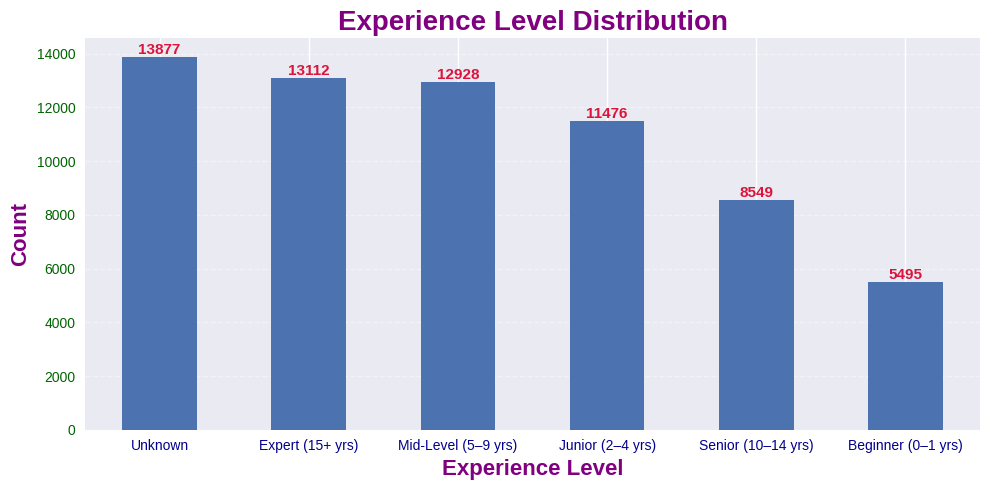

In [39]:
# Step 6: Bar chart of experience levels

ax = df["ExperienceLevel"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

# Title & axis labels
ax.set_title("Experience Level Distribution", fontsize=20, weight="bold", color="purple")
ax.set_xlabel("Experience Level", fontsize=16, color="purple", weight="bold")
ax.set_ylabel("Count", fontsize=16, color="purple", weight="bold")

#  Color for X-axis tick labels
ax.tick_params(axis="x", labelcolor="darkblue")

#  Color for Y-axis tick labels
ax.tick_params(axis="y", labelcolor="darkgreen")

# Rotate x-labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

#  Add value labels on top of bars (with color)
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center", va="bottom",
        fontsize=11,
        fontweight="bold",
        color="crimson"     # value label color
    )

# Clean layout
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.figure.tight_layout()


### Important insight
* Unknown has the highest count.
* Most people have 5+ years of experience.
* Experts (15+ yrs) and Mid-Level (5–9 yrs) are common.
* Junior (2–4 yrs) also has many entries.
* Beginners (0–1 yr) are the smallest group.